## Model Selection: Polynomial Features & Ridge vs Lasso vs ElasticNet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression,RidgeCV, LassoCV,ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.options.display.float_format = '{:.6f}'.format

In [2]:
housing = fetch_california_housing()
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [3]:
housing['target_names']

['MedHouseVal']

In [4]:
df = pd.DataFrame(housing['data'], columns= housing['feature_names'])
df['MedHouseVal']= housing['target']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325200,41.000000,6.984127,1.023810,322.000000,2.555556,37.880000,-122.230000,4.526000
1,8.301400,21.000000,6.238137,0.971880,2401.000000,2.109842,37.860000,-122.220000,3.585000
2,7.257400,52.000000,8.288136,1.073446,496.000000,2.802260,37.850000,-122.240000,3.521000
3,5.643100,52.000000,5.817352,1.073059,558.000000,2.547945,37.850000,-122.250000,3.413000
4,3.846200,52.000000,6.281853,1.081081,565.000000,2.181467,37.850000,-122.250000,3.422000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
X = df.drop(columns ='MedHouseVal')
y =df['MedHouseVal']

In [7]:
print('df shape',df.shape)
print('X shape', X.shape)
print('y.shape', y.shape)

df shape (20640, 9)
X shape (20640, 8)
y.shape (20640,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=101)

In [9]:
#Find best degree of Polynomial

results=[]
for degree in [1,2,3,4]:
    poly_pipe = Pipeline([
        ('poly',PolynomialFeatures(degree=degree,include_bias=False)),
        ('scale',StandardScaler()),
        ('model',LinearRegression())
    ])

    poly_pipe.fit(X_train,y_train)
    y_pred_train = poly_pipe.predict(X_train)
    y_pred_test = poly_pipe.predict(X_test)

    train_rmse= np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse= np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_r2 = r2_score(y_train,y_pred_train)
    test_r2 = r2_score(y_test,y_pred_test)

    results.append({
        'Degree': degree,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Gap': abs(train_r2 - test_r2)
    })   

df = pd.DataFrame(results)
df

,Degree,Train RMSE,Test RMSE,Train R²,Test R²,Gap
0,1,0.720892,0.738023,0.608210,0.597095,0.011116
1,2,0.643111,0.707734,0.688194,0.629487,0.058707
2,3,0.580318,5.301310,0.746110,-19.788820,20.534930
3,4,0.527485,4314.016740,0.790235,-13766613.516692,13766614.306927


In [10]:
results[1]

{'Degree': 2,
 'Train RMSE': np.float64(0.643110623639891),
 'Test RMSE': np.float64(0.7077335154155802),
 'Train R²': 0.6881939754796292,
 'Test R²': 0.6294873630200151,
 'Gap': 0.05870661245961417}

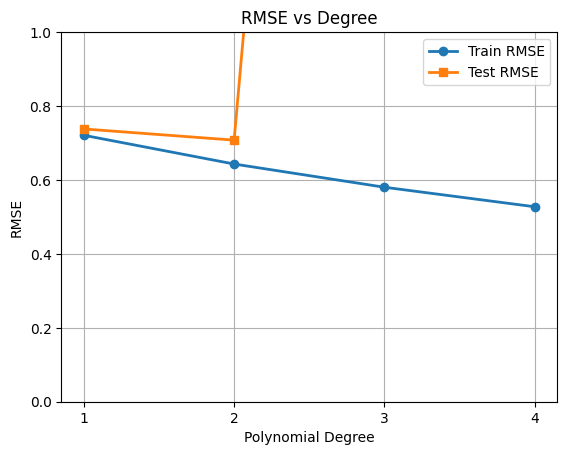

In [11]:
#RMSE vs Degree of Polynomial
plt.plot(df['Degree'], df['Train RMSE'], 'o-', label='Train RMSE', linewidth=2)
plt.plot(df['Degree'], df['Test RMSE'], 's-', label='Test RMSE', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs Degree')
plt.ylim([0, 1])
plt.xticks([1, 2, 3, 4])
plt.grid()
plt.legend();

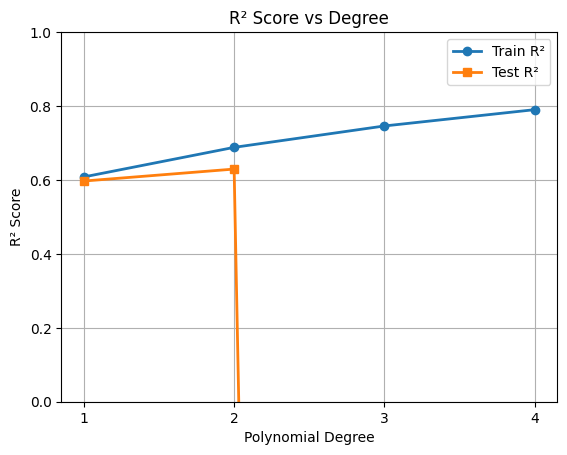

In [12]:
#R2 score vs Degree of Polynomial
plt.plot(df['Degree'], df['Train R²'], 'o-', label='Train R²', linewidth=2)
plt.plot(df['Degree'], df['Test R²'], 's-', label='Test R²', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('R² Score vs Degree')
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.grid()
plt.ylim([0, 1]);

**Best Degree of Polynomial based on R2 score and RMSE is 2.**

## Ridge Regression

### Ridge — minimise error + shrink coefficients

```
Minimise:  Σ(actual - predicted)²  +  α × Σ(coefficient²)
                                       ↑
                                  penalty term

```
- #### α controls how hard to push back against large coefficients:

```
α = 0      →  identical to Linear Regression, no penalty
α = 1      →  mild push, coefficients shrink a little
α = 100    →  strong push, coefficients shrink a lot
α = ∞      →  all coefficients forced to zero, useless model


Ridge penalty (coefficient²) looks like a bowl:
        
         \       /
          \     /
           \   /
            \_/
         never flat — always nudges toward zero but never reaches it

```

- Here RidgeCV is used

In [13]:
ridge_cv = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 4, 100)))
])
ridge_cv.fit(X_train, y_train)
y_pred_train_ridge = ridge_cv.predict(X_train)
y_pred_test_ridge = ridge_cv.predict(X_test)

train_rmse_ridge= np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
test_rmse_ridge= np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

train_r2score_ridge = r2_score(y_train,y_pred_train_ridge)
test_r2score_ridge = r2_score(y_test,y_pred_test_ridge)

best_alpha = ridge_cv.named_steps['ridge'].alpha_
print('Ridge Regression')
print('='*20)
print('Best Alpha:', best_alpha)
print('Train RMSE:', train_rmse_ridge)
print('Test RMSE :', test_rmse_ridge)
print('Train R2 Score:', train_r2score_ridge)
print('Test  R2 score:', test_r2score_ridge)

Ridge Regression
Best Alpha: 0.0050941380148163806
Train RMSE: 0.6434073380448063
Test RMSE : 0.7012508620129979
Train R2 Score: 0.6879061908337161
Test  R2 score: 0.6362438738952279


## Lasso Regression

### Lasso — minimise error + kill weak coefficients entirely
```
Minimise:  Σ(actual - predicted)²  +  α × Σ|coefficient|
                                              ↑
                                        absolute value
                                        not squared
Lasso penalty (|coefficient|) looks like a V:

          \   /
           \ /
            V
         Has a sharp corner at zero — coefficients get stuck there
         This is why Lasso produces exact zeros
                                      
```  
- ##### absolute value vs squared — is what causes Lasso to zero coefficients out completely while Ridge only shrinks them ie,Lasso does feature selection automatically.

- Here LassoCV is used (```max_iter``` to be set in Pipeline)
```
('lassocv', LassoCV(alphas=np.logspace(-3, 4, 100), max_iter=10000))
```

In [14]:
lasso_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler',StandardScaler()),
    ('lassocv', LassoCV(alphas=np.logspace(-3,4,100),max_iter=10000))
])

lasso_pipe.fit(X_train,y_train)
y_pred_train_lasso =lasso_pipe.predict(X_train)
y_pred_test_lasso =lasso_pipe.predict(X_test)

train_rmse_lasso= np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
test_rmse_lasso =np.sqrt(mean_squared_error(y_test,y_pred_test_lasso))

train_r2score_lasso = r2_score(y_train,y_pred_train_lasso)
test_r2score_lasso  = r2_score(y_test, y_pred_test_lasso)
best_alpha_lasso = lasso_pipe.named_steps['lassocv'].alpha_
                         
print('Lasso Regression')
print('='*20)

print('best alpha      ',best_alpha_lasso) 
print('Train RMSE lasso',train_rmse_lasso)
print('Test RMSE lasso ',test_rmse_lasso)
print('Train R2 score(lasso)',train_r2score_lasso)
print('Test R2 score(lasso)',test_r2score_lasso)
   

Lasso Regression
best alpha       0.02595024211399736
Train RMSE lasso 0.7386541940822541
Test RMSE lasso  0.7599189810002275
Train R2 score(lasso) 0.5886651837613495
Test R2 score(lasso) 0.5728326166077116


## Elastic Net
- combines both
```
Ridge  = L2 regularization  (sum of squared coefficients)
Lasso  = L1 regularization  (sum of absolute coefficients)
```
– ```ElasticNet(alpha=1, l1_ratio=0.5)```,penalizes: 0.5 * sum(|coef|) + 0.5 * sum(coef²)

- Effect: hybrid of Ridge + Lasso
```
l1_ratio=0 → pure Ridge
l1_ratio=1 → pure Lasso
l1_ratio=0.5 → 50/50 mix
```

In [15]:
elastic_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
     ('scaler', StandardScaler()),
     ('elastic', ElasticNetCV(
         alphas = np.logspace(-3,4,100),
         l1_ratio=[0.1,0.5,0.9],
         max_iter=10000,
         cv=5
     ))
])
    
elastic_pipe.fit(X_train,y_train)
y_pred_train_elnet = elastic_pipe.predict(X_train)
y_pred_test_elnet  = elastic_pipe.predict(X_test)

train_rmse_elnet = np.sqrt(mean_squared_error(y_train,y_pred_train_elnet))
test_rmse_elnet = np.sqrt(mean_squared_error(y_test,y_pred_test_elnet))

train_r2_elnet = r2_score(y_train, y_pred_train_elnet)
test_r2_elnet  = r2_score(y_test, y_pred_test_elnet)

best_alpha_elnet = elastic_pipe.named_steps['elastic'].alpha_

print('Elastic Net Regression')
print('='*25)

print('best alpha      ',best_alpha_elnet)
print('Train RMSE elastic',train_rmse_elnet)
print('Test RMSE elastic ',test_rmse_elnet)
print('Train R2 score  ',train_r2_elnet)
print('Test R2 score   ',test_r2_elnet) 

Elastic Net Regression
best alpha       0.02595024211399736
Train RMSE elastic 0.7364194509984631
Test RMSE elastic  0.7584294803884134
Train R2 score   0.5911503442486088
Test R2 score    0.574505538403782


## Ridge vs Lasso vs ElasticNet

In [16]:
elastic_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
     ('scaler', StandardScaler()),
     ('elastic', ElasticNetCV(
         alphas = np.logspace(-3,4,100),
         l1_ratio=[0.1,0.5,0.9],
         max_iter=10000,
         cv=5
     ))
])
    
elastic_pipe.fit(X_train,y_train)
y_pred_train_elnet = elastic_pipe.predict(X_train)
y_pred_test_elnet  = elastic_pipe.predict(X_test)

train_rmse_elnet = np.sqrt(mean_squared_error(y_train,y_pred_train_elnet))
test_rmse_elnet = np.sqrt(mean_squared_error(y_test,y_pred_test_elnet))

train_r2_elnet = r2_score(y_train, y_pred_train_elnet)
test_r2_elnet  = r2_score(y_test, y_pred_test_elnet)

best_alpha_elnet = elastic_pipe.named_steps['elastic'].alpha_

print('Elastic Net Regression')
print('='*25)

print('best alpha      ',best_alpha_elnet)
print('Train RMSE elastic',train_rmse_elnet)
print('Test RMSE elastic ',test_rmse_elnet)
print('Train R2 score  ',train_r2_elnet)
print('Test R2 score   ',test_r2_elnet) 

Elastic Net Regression
best alpha       0.02595024211399736
Train RMSE elastic 0.7364194509984631
Test RMSE elastic  0.7584294803884134
Train R2 score   0.5911503442486088
Test R2 score    0.574505538403782
